# 03 — EDA: Insurance Leads

Analyse lead profitability using **RPL (Revenue Per Lead)** as the primary KPI.

**Business context**: We pay £55 per lead (`COST_PER_LEAD`). Any lead segment with RPL < £55 is loss-making.

**Questions we want to answer**:
1. Are we profitable overall?
2. Which lead segments are profitable vs. loss-making?
3. Are there keywords we should pause?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
COST_PER_LEAD = 55

# Dark theme
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f", "axes.facecolor": "#0f0f0f",
    "axes.edgecolor": "#333333", "axes.labelcolor": "#cccccc",
    "text.color": "#cccccc", "xtick.color": "#999999", "ytick.color": "#999999",
    "grid.color": "#222222", "legend.facecolor": "#1a1a1a",
    "legend.edgecolor": "#333333", "figure.dpi": 120,
})
GREEN, RED, BLUE, AMBER, GREY = "#00c896", "#ff4d6d", "#4e9af1", "#f0a500", "#888888" 

In [2]:
leads = pd.read_parquet(DATA_DIR / "leads_clean.parquet")
print(f"Leads: {leads.shape[0]:,} rows × {leads.shape[1]} cols")
leads.head()

Leads: 7,485 rows × 20 cols


,lead_id,lead_status,premium,age,gender,smoker,current_insurance,device_type,keyword,match_type,postcode,cover_for,verification_status,pc_area,keyword_group,converted,is_invalid,high_value,age_band,created_date
0,56881023,Contacted,0.0,43,Female,no,no,Smartphone,best private health insurance uk,Exact,BT30,Self + Family,not_verified,BT,Comparison / Research,0,0,0,35-44,2025-01-01
1,34530125,Contacted,0.0,22,Female,no,no,Desktop,private healthcare,Exact,M15,Self,not_verified,M,Generic: Private Health,0,0,0,Under 25,2025-01-01
2,57700172,Contacted,0.0,58,Female,yes,no,Smartphone,private medical insurance uk,Exact,LL20,Self,not_verified,LL,Generic: Private Health,0,0,0,55-64,2025-01-01
3,26588051,Quoted,0.0,43,Female,no,no,Smartphone,private medical insurance uk,Exact,SN11,Self,not_verified,SN,Generic: Private Health,0,0,0,35-44,2025-01-01
4,71395741,Sold,2182.2,56,Male,no,no,Desktop,bupa health insurance,Exact,HA6,Self,verified,HA,Brand: Bupa,1,0,1,55-64,2025-01-01


## 1 · Commercial Summary

The headline numbers: are we making or losing money?

In [3]:
total_leads = len(leads)
total_sold = leads["converted"].sum()
total_invalid = leads["is_invalid"].sum()
total_premium = leads["premium"].sum()
conv_rate = total_sold / total_leads
total_cost = total_leads * COST_PER_LEAD
rpl = total_premium / total_leads
net_per_lead = rpl - COST_PER_LEAD

print("COMMERCIAL SUMMARY")
print("=" * 40)
print(f"  Total leads:    {total_leads:,}")
print(f"  Conversions:    {total_sold:,} ({conv_rate:.1%})")
print(f"  Invalid:        {total_invalid:,} ({total_invalid/total_leads:.1%})")
print(f"  ─────────────────────────")
print(f"  Total revenue:  £{total_premium:,.0f}")
print(f"  Total cost:     £{total_cost:,.0f}")
print(f"  Net profit:     £{total_premium - total_cost:,.0f}")
print(f"  ─────────────────────────")
print(f"  RPL:            £{rpl:.2f}")
print(f"  Net / Lead:     £{net_per_lead:.2f}")
print(f"  ROI:            {(total_premium - total_cost) / total_cost * 100:.1f}%")

COMMERCIAL SUMMARY
  Total leads:    7,485
  Conversions:    367 (4.9%)
  Invalid:        326 (4.4%)
  ─────────────────────────
  Total revenue:  £573,400
  Total cost:     £411,675
  Net profit:     £161,725
  ─────────────────────────
  RPL:            £76.61
  Net / Lead:     £21.61
  ROI:            39.3%


## 2 · Funnel Breakdown

Where do leads end up? This shows the overall pipeline health.

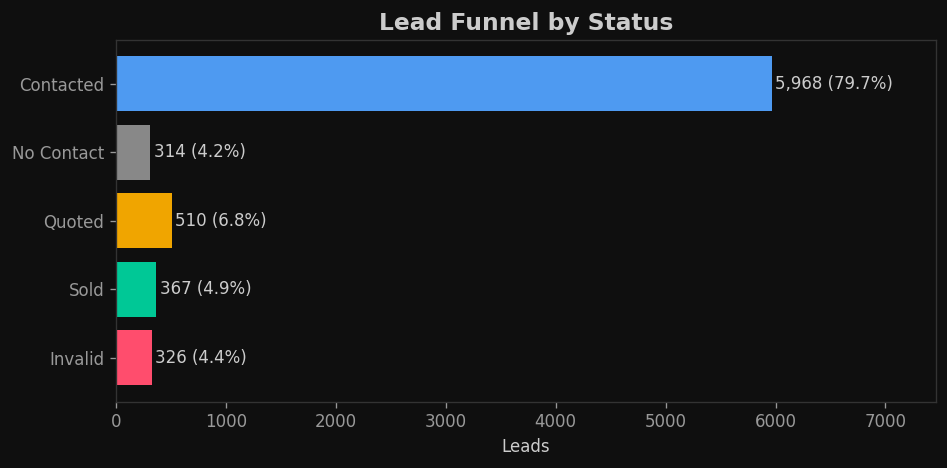

In [4]:
funnel = leads["lead_status"].value_counts().reindex(
    ["Contacted", "No Contact", "Quoted", "Sold", "Invalid"])

fig, ax = plt.subplots(figsize=(8, 4))
colors = [BLUE, GREY, AMBER, GREEN, RED]
bars = ax.barh(funnel.index, funnel.values, color=colors)
for bar, val in zip(bars, funnel.values):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f"{val:,} ({val/total_leads*100:.1f}%)", va="center", fontsize=10, color="#cccccc")
ax.set_xlabel("Leads")
ax.set_title("Lead Funnel by Status", fontsize=14, fontweight="bold")
ax.invert_yaxis()
ax.set_xlim(0, funnel.max() * 1.25)
plt.tight_layout()
plt.show()

## 3 · Dimensional Analysis

Break down RPL by the most important lead attributes.

We use a simple helper to compute KPIs for any column — then look at the 4 most impactful dimensions.

In [5]:
def analyse_dimension(df, col):
    """Compute KPIs per value of a categorical column."""
    s = df.groupby(col).agg(
        leads=("lead_id", "count"), sales=("converted", "sum"),
        invalids=("is_invalid", "sum"), revenue=("premium", "sum"))
    s["conv_%"] = (s["sales"] / s["leads"] * 100).round(1)
    s["rpl"] = (s["revenue"] / s["leads"]).round(2)
    s["net_per_lead"] = (s["rpl"] - COST_PER_LEAD).round(2)
    return s.sort_values("rpl", ascending=False)

In [6]:
# Verification status — the #1 driver
v = analyse_dimension(leads, "verification_status")
print("VERIFICATION STATUS")
print(v[["leads", "sales", "conv_%", "rpl", "net_per_lead"]].to_string())

VERIFICATION STATUS
                     leads  sales  conv_%     rpl  net_per_lead
verification_status                                            
verified              1554    147     9.5  133.39         78.39
not_verified          5931    220     3.7   61.73          6.73


In [7]:
# Device type
d = analyse_dimension(leads, "device_type")
print("\nDEVICE TYPE")
print(d[["leads", "sales", "conv_%", "rpl", "net_per_lead"]].to_string())


DEVICE TYPE
             leads  sales  conv_%     rpl  net_per_lead
device_type                                            
Tablet         319     22     6.9  169.02        114.02
Desktop       1768     86     4.9  101.64         46.64
Smartphone    5398    259     4.8   62.95          7.95


In [8]:
# Keyword group
k = analyse_dimension(leads, "keyword_group")
print("\nKEYWORD GROUP")
print(k[["leads", "sales", "conv_%", "rpl", "net_per_lead"]].to_string())


KEYWORD GROUP
                           leads  sales  conv_%     rpl  net_per_lead
keyword_group                                                        
Brand: Other                  89     11    12.4  252.59        197.59
Price / Quote Intent         419     16     3.8   85.87         30.87
Generic: Health Insurance   1219     64     5.3   75.34         20.34
Generic: Private Health     3484    182     5.2   75.11         20.11
Brand: Bupa                 1594     76     4.8   74.99         19.99
Comparison / Research        488     14     2.9   74.85         19.85
Other                        192      4     2.1   27.83        -27.17


In [9]:
# Current insurance
i = analyse_dimension(leads, "current_insurance")
print("\nCURRENT INSURANCE")
print(i[["leads", "sales", "conv_%", "rpl", "net_per_lead"]].to_string())


CURRENT INSURANCE
                   leads  sales  conv_%     rpl  net_per_lead
current_insurance                                            
yes private          951     75     7.9  168.05        113.05
yes company          392     17     4.3  110.65         55.65
no                  6142    275     4.5   60.27          5.27


### RPL Comparison Chart

Green = profitable (above £55), Red = loss-making.

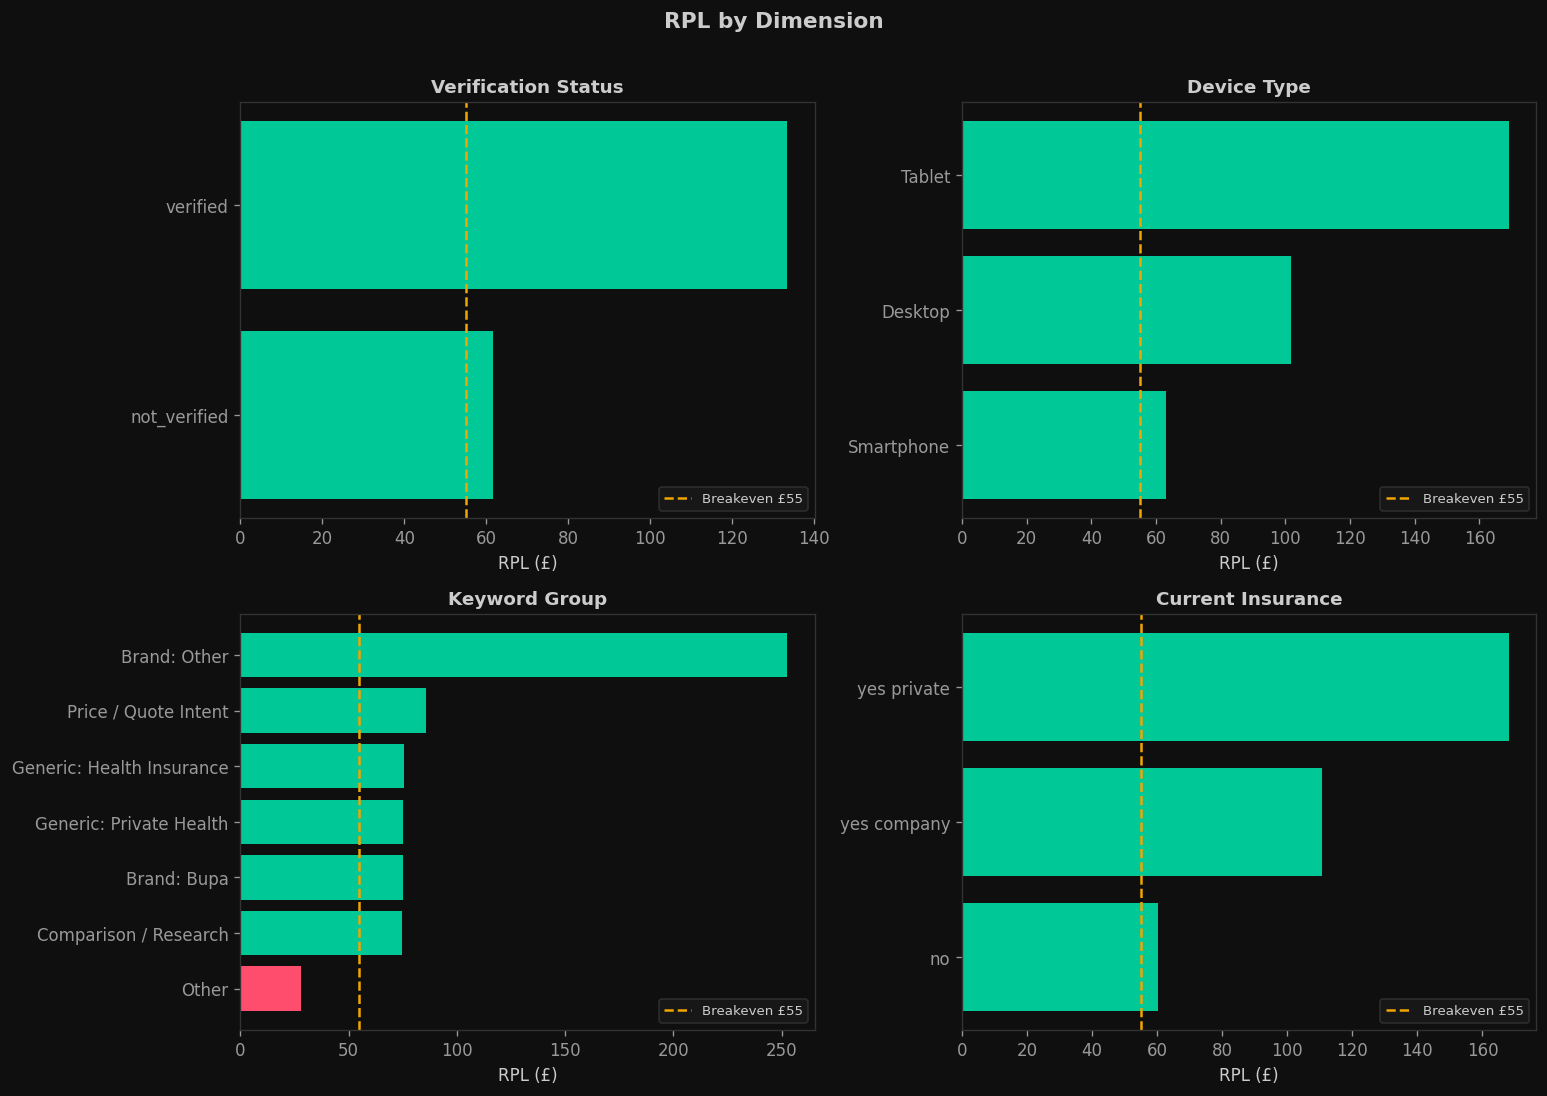

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

def plot_rpl(ax, stats, title):
    vals = stats.sort_values("rpl", ascending=True)
    colors_list = [GREEN if x >= COST_PER_LEAD else RED for x in vals["rpl"]]
    ax.barh(vals.index.astype(str), vals["rpl"], color=colors_list)
    ax.axvline(COST_PER_LEAD, color=AMBER, ls="--", lw=1.5, label=f"Breakeven £{COST_PER_LEAD}")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("RPL (£)")
    ax.legend(fontsize=8, loc="lower right")

plot_rpl(axes[0,0], v, "Verification Status")
plot_rpl(axes[0,1], d, "Device Type")
plot_rpl(axes[1,0], k, "Keyword Group")
plot_rpl(axes[1,1], i, "Current Insurance")

plt.suptitle("RPL by Dimension", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 4 · Cross-Dimensional View

Signals combine — a verified tablet lead is worth much more than an unverified smartphone lead.

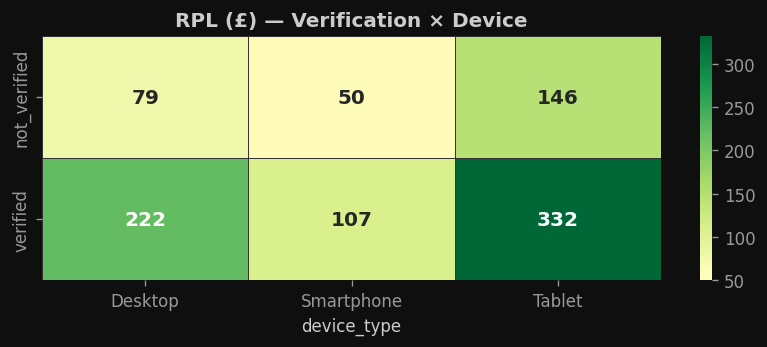

In [11]:
# Verification × Device Type — RPL heatmap
cross = (
    leads.groupby(["verification_status", "device_type"])
    .agg(leads=("lead_id", "count"), revenue=("premium", "sum"))
)
cross["rpl"] = (cross["revenue"] / cross["leads"]).round(2)

pivot = cross["rpl"].unstack("device_type")
fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="RdYlGn", center=COST_PER_LEAD,
            linewidths=0.5, linecolor="#333333", ax=ax,
            annot_kws={"fontsize": 12, "fontweight": "bold"})
ax.set_title("RPL (£) — Verification × Device", fontsize=12, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5 · Zero-Sale Keywords

Keywords with decent volume but zero conversions — pure waste at £55 per lead.

In [12]:
kw_perf = leads.groupby("keyword").agg(
    leads=("lead_id", "count"), sales=("converted", "sum")).reset_index()

zero_sale = kw_perf[(kw_perf["leads"] >= 15) & (kw_perf["sales"] == 0)].copy()
zero_sale["wasted_spend"] = zero_sale["leads"] * COST_PER_LEAD
zero_sale = zero_sale.sort_values("leads", ascending=False)

print(f"Keywords with ≥15 leads and 0 conversions: {len(zero_sale)}")
print(f"Total wasted leads: {zero_sale['leads'].sum():,}")
print(f"Total wasted spend: £{zero_sale['wasted_spend'].sum():,}")
print()
print(zero_sale[["keyword", "leads", "wasted_spend"]].to_string(index=False))

Keywords with ≥15 leads and 0 conversions: 11
Total wasted leads: 290
Total wasted spend: £15,950

                                           keyword  leads  wasted_spend
                  private medical insurance policy     65          3575
health insurance for people with pre existing cond     45          2475
                          medical shield insurance     38          2090
      health insurance for pre existing conditions     25          1375
 private medical insurance for existing conditions     19          1045
      insurance for undiagnosed medical conditions     18           990
         medical insurance pre existing conditions     17           935
                       '+health +insurance +policy     16           880
health insurance that covers pre existing conditio     16           880
 health insurance to cover pre existing conditions     16           880
                         health insurance plans uk     15           825


## 6 · Key Findings

In [13]:
# Print findings with actual values
print("KEY FINDINGS")
print("=" * 45)
print(f"1. RPL: £{rpl:.2f} | Net/Lead: £{net_per_lead:.2f} | ROI: {(total_premium - total_cost) / total_cost * 100:.1f}%")
print(f"2. Verified conv rate much higher than unverified")
print(f"3. {len(zero_sale)} zero-sale keywords wasting £{zero_sale['wasted_spend'].sum():,}")
print(f"4. Best combo: verified + tablet | Worst: unverified + smartphone")

KEY FINDINGS
1. RPL: £76.61 | Net/Lead: £21.61 | ROI: 39.3%
2. Verified conv rate much higher than unverified
3. 11 zero-sale keywords wasting £15,950
4. Best combo: verified + tablet | Worst: unverified + smartphone
